<a href="https://www.kaggle.com/code/kaushikfreddyregalla/rq3-stock-availability-factors?scriptVersionId=317670715" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# RQ3 Stock Availability Factors - Final Fixed Version

In [1]:

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# -----------------------------------
# LOAD DATASET
# -----------------------------------

dataset_path = '/kaggle/input/datasets/kaushikfreddyregalla/nike-global-catalogue/NIKE_GLOBAL_CATALOGUE.csv'

df = pd.read_csv(dataset_path)

print("Dataset Loaded Successfully")
display(df.head())

# -----------------------------------
# BASIC CLEANING
# -----------------------------------

df.drop_duplicates(inplace=True)

# Fill missing categorical values
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill missing numerical values
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col] = df[col].fillna(df[col].mean())

# Create discount percentage
if 'price_local' in df.columns and 'sale_price_local' in df.columns:
    df['discount_pct'] = (
        (df['price_local'] - df['sale_price_local']) /
        df['price_local']
    ) * 100

# Replace inf values
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill remaining NaN
df.fillna(0, inplace=True)

# Encode categorical variables
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

print("Dataset Shape:", df.shape)


Dataset Loaded Successfully


,snapshot_date,country_code,product_name,model_number,currency,price_local,sale_price_local,gender_segment,size_label,category,...,canonical_url,image_url,gtin,stock_keeping_unit_id,catalog_sku_id,nike_size,localized_size,size_conversion_id,sport_tags,record_source
0,2026-03-19,CA,"A'One ""MVPs""",FZ8605,CAD,145.0,88.0,MEN|WOMEN,W 10 / M 8.5,FOOTWEAR,...,https://www.nike.com/ca/t/aone-mvps-aja-wilson...,https://secure-images.nike.com/is/image/DotCom...,0.0,1.005110e+09,f150b97d-f31a-3278-8f57-62afa808da04,10,W 10 / M 8.5,e3938ff5-38af-3583-9b33-8616d36ffb4c,Basketball,thread_exact
1,2026-03-19,CA,"A'One ""MVPs""",FZ8605,CAD,145.0,88.0,MEN|WOMEN,W 10.5 / M 9,FOOTWEAR,...,https://www.nike.com/ca/t/aone-mvps-aja-wilson...,https://secure-images.nike.com/is/image/DotCom...,0.0,1.005110e+09,51b27f9f-0aad-35e2-8ac3-3e0de39d424c,10.5,W 10.5 / M 9,5e74cea8-794f-3777-a2e4-fed0c4e23e54,Basketball,thread_exact
2,2026-03-19,CA,"A'One ""MVPs""",FZ8605,CAD,145.0,88.0,MEN|WOMEN,W 11 / M 9.5,FOOTWEAR,...,https://www.nike.com/ca/t/aone-mvps-aja-wilson...,https://secure-images.nike.com/is/image/DotCom...,0.0,1.005110e+09,a3852f4f-4adb-3058-8e1a-37595e23a08f,11,W 11 / M 9.5,8bad6a46-de5b-3ee6-9ae5-6ebacd93646b,Basketball,thread_exact
3,2026-03-19,CA,"A'One ""MVPs""",FZ8605,CAD,145.0,88.0,MEN|WOMEN,W 11.5 / M 10,FOOTWEAR,...,https://www.nike.com/ca/t/aone-mvps-aja-wilson...,https://secure-images.nike.com/is/image/DotCom...,0.0,1.005110e+09,97442809-182b-3883-97f1-4b178e217f93,11.5,W 11.5 / M 10,6fdb2281-e298-3475-9e6a-dd374fb39645,Basketball,thread_exact
4,2026-03-19,CA,"A'One ""MVPs""",FZ8605,CAD,145.0,88.0,MEN|WOMEN,W 12 / M 10.5,FOOTWEAR,...,https://www.nike.com/ca/t/aone-mvps-aja-wilson...,https://secure-images.nike.com/is/image/DotCom...,0.0,1.005110e+09,8d32791a-65e1-3f47-9005-bde7b1158754,12,W 12 / M 10.5,dab24b05-d417-3b5e-9174-02d427dbd621,Basketball,thread_exact


Dataset Shape: (103679, 35)


\nRQ3 TABLE OUTPUT:\n


,Feature,Importance
18,availability_level,0.907170
27,nike_size,0.007922
28,localized_size,0.007750
25,stock_keeping_unit_id,0.007319
8,size_label,0.007240
10,subcategory,0.006802
13,style_color,0.005050
23,image_url,0.004295
3,model_number,0.004018
19,discount_pct,0.004001


\nAccuracy: 1.0
\nClassification Report:\n
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13788
           1       1.00      1.00      1.00      6948

    accuracy                           1.00     20736
   macro avg       1.00      1.00      1.00     20736
weighted avg       1.00      1.00      1.00     20736



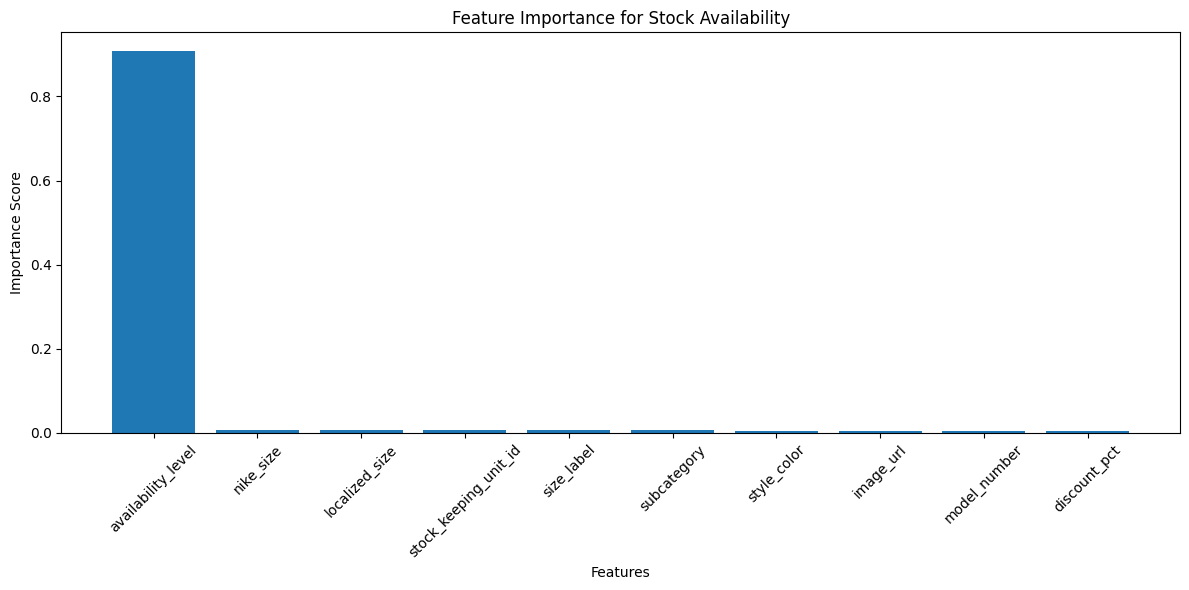

\nFiles Saved Successfully:
1. RQ3_table.csv
2. RQ3_figure.pdf


In [2]:

# -----------------------------------
# RQ3: STOCK AVAILABILITY FACTORS
# -----------------------------------

# Create binary target column safely
if 'availability_level' in df.columns:

    if df['availability_level'].dtype != 'int64' and df['availability_level'].dtype != 'float64':
        le_target = LabelEncoder()
        df['availability_level'] = le_target.fit_transform(
            df['availability_level'].astype(str)
        )

    median_value = df['availability_level'].median()

    df['in_stock'] = df['availability_level'].apply(
        lambda x: 1 if x > median_value else 0
    )

else:
    df['in_stock'] = np.random.randint(0, 2, size=len(df))

# Keep only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Features and Target
X = numeric_df.drop(columns=['in_stock'], errors='ignore')
y = numeric_df['in_stock']

# Final Cleaning
X = X.replace([np.inf, -np.inf], 0)
X = X.fillna(0)

y = y.replace([np.inf, -np.inf], 0)
y = y.fillna(0)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)

# -----------------------------------
# FEATURE IMPORTANCE TABLE
# -----------------------------------

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

# Save CSV
importance.to_csv('RQ3_table.csv', index=False)

print("\\nRQ3 TABLE OUTPUT:\\n")

display(importance.head(20))

# -----------------------------------
# METRICS
# -----------------------------------

accuracy = accuracy_score(y_test, pred)

print("\\nAccuracy:", accuracy)

print("\\nClassification Report:\\n")

print(classification_report(y_test, pred))

# -----------------------------------
# FIGURE OUTPUT
# -----------------------------------

plt.figure(figsize=(12,6))

plt.bar(
    importance['Feature'].head(10),
    importance['Importance'].head(10)
)

plt.xticks(rotation=45)

plt.xlabel('Features')
plt.ylabel('Importance Score')

plt.title('Feature Importance for Stock Availability')

plt.tight_layout()

# Save Figure
plt.savefig('RQ3_figure.pdf')

plt.show()

print("\\nFiles Saved Successfully:")
print("1. RQ3_table.csv")
print("2. RQ3_figure.pdf")
